In [1]:
import os
import glob
import ee
import geemap
import json
import requests
import folium
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import io
import zipfile

from IPython.display import display, HTML, clear_output
from PIL import Image
from pyproj import Transformer   
from datetime import datetime  

## Import the raster file to get the metadata

We need the information from the raster as the json file needs to be in reference to the origin and transformation of the tif file.

Shape of the raster (rows, columns):
(3422, 4380)


Raster metadata:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 4380, 'height': 3422, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 134.42767203983848,
       0.0, -8.983152841195215e-05, -13.26479297989409)}


Affine transformation parameters:
| 0.00, 0.00, 134.43|
| 0.00,-0.00,-13.26|
| 0.00, 0.00, 1.00|


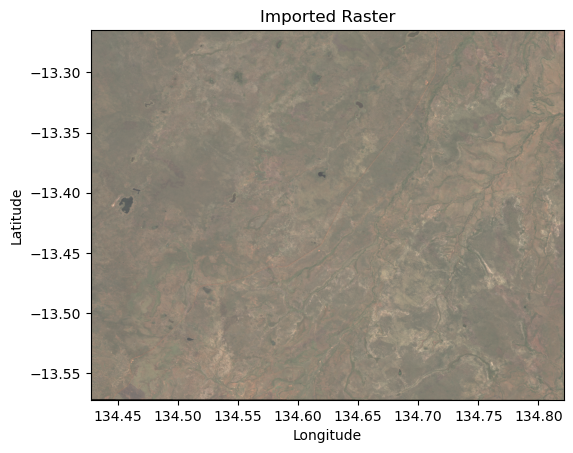

In [2]:
image_name = '2024-06_mimal_test_S2'

tif_base_dir = 'cookie-cutting/'
tif_path = os.path.join(tif_base_dir, image_name + '.tif')

with rasterio.open(tif_path) as raster:
    # Read the raster band
    imported_raster = raster.read(1)
    # Read the first three bands for an RGB preview
    rgb_raster = raster.read([1, 2, 3])
    rgb_raster = np.transpose(rgb_raster, (1, 2, 0))
    rgb_raster = rgb_raster.astype(np.float32)
    rgb_raster = (rgb_raster - rgb_raster.min()) / (rgb_raster.max() - rgb_raster.min() + 1e-9)
    # Get the metadata of the raster
    imported_raster_meta = raster.meta
    # Get the raster transform parameters
    raster_transform = raster.transform
    raster_bounds = raster.bounds

print("Shape of the raster (rows, columns):")
print(imported_raster.shape)
print("\n")

print("Raster metadata:")
print(imported_raster_meta)
print("\n")

print("Affine transformation parameters:")
print(raster_transform)

# Plot the raster as RGB using the original coordinates
import matplotlib.pyplot as plt
plt.imshow(
    rgb_raster,
    extent=(raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top),
    origin='upper',
)
plt.title('Imported Raster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Account for the png padding

As the png has padding, we need to figure out how much to add to the x and y coordinates to get the correct position for the labels in the png file.

This function will be different if there is padding on both sides and the top and bottom of the image. I've just accounted for padding on the left and top of the image by adding the difference in between the png size and the raster size to the x (difference in width) and y (difference in height) coordinates.

If the padding is consistent (e.g. tile_size - stride), we can just add that padding to the x and y coordinates. In that case, set width_diff and height_diff to the padding amount for the x and y axes respectively.

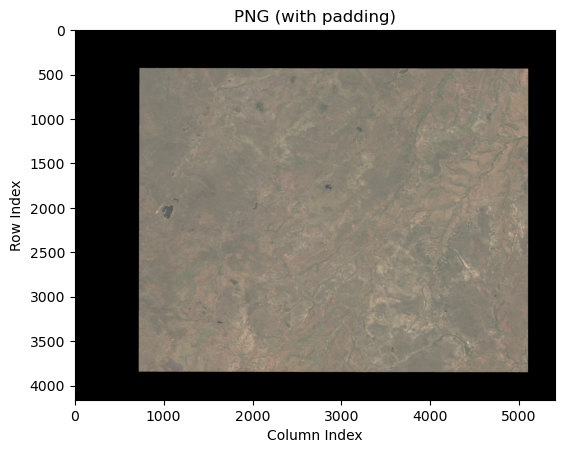

In [3]:
Image.MAX_IMAGE_PIXELS = 933120000 # change to greater than the nnumber of pixels (only needed if there's a warning)

# Base directory for the png image
png_base_dir = 'cookie-cutting/'

# Load the png image
image = Image.open(f'{png_base_dir}{image_name}.png')

# Convert the image to a numpy array
pixel_data = np.array(image)

# Plot the image data in the png to ensure they match
plt.imshow(pixel_data)
plt.title('PNG (with padding)')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

## Get image information

In [4]:
# Get image information
png_width, png_height = image.size
print(f'Image size: ({png_width}, {png_height})')

# Calculate the different in the width and height of the image and the raster
width_diff = png_width - imported_raster.shape[1]
height_diff = png_height - imported_raster.shape[0]
print(f'Difference in width: {width_diff}')
print(f'Difference in height: {height_diff}')


# if using images with padded left and right (and top and bottom)
tile_size = 416
stride = 104
min_pad = tile_size - stride
# subtract the padding on the right and bottom from the differences
width_diff = width_diff - min_pad
height_diff = height_diff - min_pad
print(f'Difference in width after removing right padding: {width_diff}')
print(f'Difference in height after removing bottom padding: {height_diff}')

Image size: (5408, 4160)
Difference in width: 1028
Difference in height: 738
Difference in width after removing right padding: 716
Difference in height after removing bottom padding: 426


In [5]:
json_path = os.path.join('cookie-cutting', f'{image_name}.json')
with open(json_path, 'r') as f:
    label_data = json.load(f)

# LabelMe stores box corners in PNG pixel coordinates, which include padding.
left_pad = (png_width - imported_raster.shape[1]) - min_pad
top_pad = (png_height - imported_raster.shape[0]) - min_pad

def png_pixel_to_lonlat(x_png, y_png):
    col = x_png - left_pad
    row = y_png - top_pad
    lon, lat = raster_transform * (col, row)
    return lon, lat

bbox_records = []
for shape in label_data['shapes']:
    (x1, y1), (x2, y2) = shape['points']
    x_min, x_max = sorted([x1, x2])
    y_min, y_max = sorted([y1, y2])

    corners = {
        'top_left': png_pixel_to_lonlat(x_min, y_min),
        'top_right': png_pixel_to_lonlat(x_max, y_min),
        'bottom_right': png_pixel_to_lonlat(x_max, y_max),
        'bottom_left': png_pixel_to_lonlat(x_min, y_max),
    }
    center_lon, center_lat = png_pixel_to_lonlat((x_min + x_max) / 2, (y_min + y_max) / 2)

    bbox_records.append({
        'label': shape['label'],
        'x_min_png': x_min,
        'y_min_png': y_min,
        'x_max_png': x_max,
        'y_max_png': y_max,
        'top_left_lon': corners['top_left'][0],
        'top_left_lat': corners['top_left'][1],
        'top_right_lon': corners['top_right'][0],
        'top_right_lat': corners['top_right'][1],
        'bottom_right_lon': corners['bottom_right'][0],
        'bottom_right_lat': corners['bottom_right'][1],
        'bottom_left_lon': corners['bottom_left'][0],
        'bottom_left_lat': corners['bottom_left'][1],
        'center_lon': center_lon,
        'center_lat': center_lat,
    })

bbox_df = pd.DataFrame(bbox_records)
bbox_df

,label,x_min_png,y_min_png,x_max_png,y_max_png,top_left_lon,top_left_lat,top_right_lon,top_right_lat,bottom_right_lon,bottom_right_lat,bottom_left_lon,bottom_left_lat,center_lon,center_lat
0,WH_wet,1485.210578,3469.863767,1502.729643,3483.531629,134.496771,-13.538228,134.498345,-13.538228,134.498345,-13.539456,134.496771,-13.539456,134.497558,-13.538842
1,Dry_WH,1317.820691,3607.445726,1337.607607,3617.246978,134.481735,-13.550587,134.483512,-13.550587,134.483512,-13.551468,134.481735,-13.551468,134.482623,-13.551027
2,WH_swamp,1597.312685,3269.092400,1671.329790,3303.405068,134.506842,-13.520192,134.513491,-13.520192,134.513491,-13.523275,134.506842,-13.523275,134.510166,-13.521733
3,WH_swamp,2211.721975,1735.673981,2347.609762,1819.685097,134.562035,-13.382443,134.574242,-13.382443,134.574242,-13.389990,134.562035,-13.389990,134.568139,-13.386216
4,WH_swamp,2215.493840,1590.519480,2316.212202,1656.841345,134.562374,-13.369404,134.571422,-13.369404,134.571422,-13.375361,134.562374,-13.375361,134.566898,-13.372382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Dry_WH,1444.160841,2087.533797,1455.555236,2094.994880,134.493084,-13.414051,134.494107,-13.414051,134.494107,-13.414721,134.493084,-13.414721,134.493596,-13.414386
183,WH_wet,1639.054061,647.528802,1682.246332,662.113332,134.510591,-13.284693,134.514471,-13.284693,134.514471,-13.286003,134.510591,-13.286003,134.512531,-13.285348
184,WH_sink,2963.556765,3767.487499,2985.879895,3779.599334,134.629573,-13.564964,134.631579,-13.564964,134.631579,-13.566052,134.629573,-13.566052,134.630576,-13.565508
185,WH_sink,4690.631632,1466.159258,4698.872432,1484.846193,134.784719,-13.358232,134.785460,-13.358232,134.785460,-13.359911,134.784719,-13.359911,134.785089,-13.359071


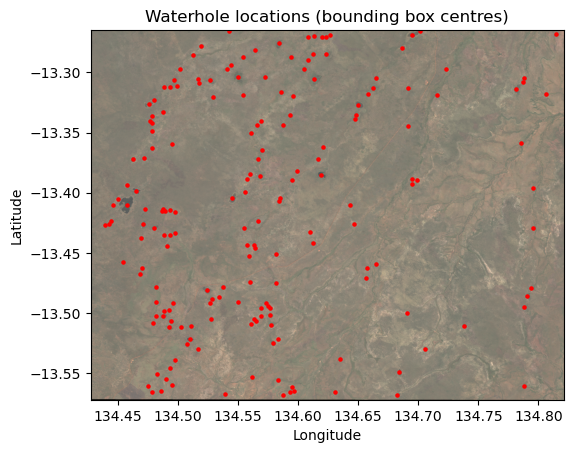

In [6]:
# Plot the centre points of the bounding boxes on the raster
plt.imshow(
    rgb_raster,
    extent=(raster_bounds.left, raster_bounds.right, raster_bounds.bottom, raster_bounds.top),
    origin='upper',
)
plt.scatter(bbox_df['center_lon'], bbox_df['center_lat'], c='red', s=5)
plt.title('Waterhole locations (bounding box centres)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()  

# Initialise GEE

You will need to authenticate your Google account the first time you run this. 

In [7]:
# Initialize Earth Engine
try:
    ee.Initialize()
    print("Earth Engine already initialized")
except Exception as e:
    ee.Authenticate()
    ee.Initialize()
    print("Earth Engine initialized")


Successfully saved authorization token.
Earth Engine initialized


## Create AOIs from bounding box centres

Use the centres of the labelled bounding boxes as the AOI seed points, then buffer each one into a rectangular region for downstream sampling.

In [8]:
half_side_m = 750  # half the side length in metres

# Turn each bounding-box centre into a rectangular AOI
def bbox_center_to_rect(row):
    point = ee.Geometry.Point([float(row['center_lon']), float(row['center_lat'])])
    return ee.Feature(
        point.buffer(half_side_m).bounds(),
        {
            'lon': float(row['center_lon']),
            'lat': float(row['center_lat']),
            'label': row['label'],
        },
    )

rect_fc = ee.FeatureCollection([
    bbox_center_to_rect(row)
    for _, row in bbox_df.iterrows()
])
print(f'Created {bbox_df.shape[0]} AOIs from bounding-box centres')

Created 187 AOIs from bounding-box centres


### Plot the sampled AOIs

In [9]:
basemap = geemap.Map(lite_mode=True)
basemap.add_basemap("SATELLITE")
basemap.set_center(134.6, -13.425, 11)  # lon, lat, zoom — roughly central North Australia

# Style: red outlines, no fill
basemap.addLayer(
    rect_fc.style(color='red', fillColor='FF000033', width=2),  # last 2 hex digits = alpha
    {},
    'Sampled AOIs',
)

# basemap

# Clear previous outputs before displaying new map
clear_output(wait=True)
basemap.to_html(filename='satellite_map3.html')
HTML('satellite_map3.html')

# Get the AlphaEarth annual embeddings

We use [`GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL), the public release of the AlphaEarth Foundations model.

Key properties, and how they differ from the Sentinel-2 workflow:

- **64 bands** (`A00`–`A63`), each a single axis of a learned embedding space. Individual bands have *no* physical meaning on their own — only the 64-d vector as a whole does.
- Each pixel vector is **unit length**, so individual band values sit in roughly $[-0.3, 0.3]$, and the **dot product of two pixel vectors is their cosine similarity** in $[-1, 1]$. This is what makes similarity and change detection so cheap (see below).
- **10 m** resolution, matching the S2 pipeline.
- **One image per calendar year**, summarising the whole year's multi-sensor trajectory (Sentinel-1/2, Landsat, LiDAR and others). Clouds, scan lines and missing data are already handled by the model, so **no cloud masking is required** — that whole step from the S2 notebook disappears.
- Coverage runs from **2017** onwards. The most recent year is only published some months after it ends, so a year in your list that isn't available yet is simply skipped with a warning.

Because the images are tiled in UTM, an AOI can straddle two tiles, so we `mosaic()` the year's images before clipping.


In [10]:
EMBEDDING_COLLECTION = 'GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL'
EMBEDDING_BANDS = [f'A{i:02d}' for i in range(64)]


def get_annual_embeddings(years, aoi, verbose=True):
    """Return an ImageCollection with one clipped AlphaEarth embedding image per year.

    Replaces get_monthly_composites() from the Sentinel-2 notebook. No cloud masking
    is needed: each annual image is already a gap-free summary of the year.

    Years with no published image (e.g. the current year) are skipped with a warning.
    """
    collection = ee.ImageCollection(EMBEDDING_COLLECTION).filterBounds(aoi)

    images = []
    for year in years:
        yearly = collection.filterDate(f'{year}-01-01', f'{year + 1}-01-01')
        count = yearly.size().getInfo()

        if count == 0:
            if verbose:
                print(f'  Skipping {year}: no AlphaEarth image available for this AOI')
            continue

        if verbose:
            print(f'  Found {count} AlphaEarth tile(s) for {year}')

        # mosaic() in case the AOI straddles two UTM tiles, then clip to the AOI
        image = (yearly.mosaic()
                       .select(EMBEDDING_BANDS)
                       .toFloat()
                       .clip(aoi)
                       .set({
                           'system:index': str(year),
                           'year': year,
                           'system:time_start': ee.Date(f'{year}-01-01').millis(),
                       }))
        images.append(image)

    return ee.ImageCollection.fromImages(images)

# Visualising the embeddings

## Which bands should we display?

The dataset docs suggest an arbitrary triplet:

```js
var visParams = {min: -0.3, max: 0.3, bands: ['A01', 'A16', 'A09']};
```

That triplet has **no special meaning** — the docs are explicit that you can pick any three bands, since each is just one axis of the embedding space. There is no "water band" to reach for. So for detecting waterholes and tracking how they change, three approaches are given below, in increasing order of usefulness for our purpose:

1. **Fixed band triplet** (`A01`, `A16`, `A09`, stretched over $[-0.3, 0.3]$). Arbitrary, but *deterministic and identical across every AOI and every year*, which is exactly what you want when the PNGs are training inputs for a detection model. This is the default for the PNG export at the end of the notebook.

2. **PCA → RGB.** Project the 64 bands onto their first three principal components. This gives far better visual separation of water / dry ground / vegetation than an arbitrary triplet, because it puts the axes of greatest variance on screen. **Caveat:** a PCA fitted per-AOI-per-year is *not* comparable between AOIs or years — the axes are redefined each time. For anything comparative, fit the basis once and reuse it (which is what the PNG exporter's `pca` mode does).

3. **Cosine similarity to a reference water pixel.** Since every pixel vector is unit length, the dot product of a pixel with a known-water pixel *is* the cosine similarity. This produces a directly interpretable "how water-like is this pixel" map in $[-1, 1]$, and it is stable across years because the embedding space itself is stable. We seed the reference from one of your own labelled `WH_wet` boxes.

Building on (3), the **year-to-year change** map is $1 - \cos(\mathbf{e}_{t_1}, \mathbf{e}_{t_2})$ at each pixel: near 0 where the surface behaved the same in both years, and large where it changed. This is the most direct read on waterhole drying/filling between years.


In [11]:
# --- 1. Fixed band triplet (the dataset docs' default) -----------------------
# Arbitrary axes, but identical for every AOI and every year, so images are
# directly comparable. Values are unit-vector components, hence the [-0.3, 0.3].
RGB_BANDS = ['A01', 'A16', 'A09']
RGB_VIS = {'bands': RGB_BANDS, 'min': -0.3, 'max': 0.3}


# --- 2. PCA -> RGB -----------------------------------------------------------
def embedding_pca_rgb(image, region, scale=10, n_components=3):
    """Project the 64 embedding bands onto their first n principal components.

    Note the basis is fitted on `region` only, so PCs from different AOIs or
    years are NOT comparable with each other. Good for looking, not for stacking.
    """
    band_names = image.bandNames()

    # Centre the image on the regional mean before projecting
    means = ee.Image.constant(
        image.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region, scale=scale,
            maxPixels=1e9, bestEffort=True,
        ).values(band_names)
    )
    centered = image.subtract(means)

    arrays = centered.toArray()
    covar = arrays.reduceRegion(
        reducer=ee.Reducer.centeredCovariance(), geometry=region, scale=scale,
        maxPixels=1e9, bestEffort=True,
    )
    # eigen() returns [eigenvalue, eigenvector...] per row, sorted descending
    eigen_vectors = ee.Array(ee.Dictionary(covar).get('array')).eigen().slice(1, 1)

    pc_names = [f'pc{i + 1}' for i in range(n_components)]
    return (ee.Image(eigen_vectors.slice(0, 0, n_components))
              .matrixMultiply(arrays.toArray(1))
              .arrayProject([0])
              .arrayFlatten([pc_names]))


def percentile_vis(image, region, scale=10, low=2, high=98):
    """Build a vis dict by stretching each band between two percentiles."""
    band_names = image.bandNames().getInfo()
    stats = image.reduceRegion(
        reducer=ee.Reducer.percentile([low, high]), geometry=region, scale=scale,
        maxPixels=1e9, bestEffort=True,
    ).getInfo()
    return {
        'bands': band_names,
        'min': [stats[f'{b}_p{low}'] for b in band_names],
        'max': [stats[f'{b}_p{high}'] for b in band_names],
    }


# --- 3. Cosine similarity to a reference pixel -------------------------------
def reference_embedding(image, point, scale=10):
    """Pull the 64-d embedding vector at a single point as a constant image."""
    band_names = image.bandNames()
    values = image.reduceRegion(
        reducer=ee.Reducer.first(), geometry=point, scale=scale,
    ).values(band_names)
    return ee.Image.constant(values).rename(band_names)


def similarity_to_reference(image, reference_image):
    """Cosine similarity in [-1, 1]: a plain dot product, as vectors are unit length."""
    return image.multiply(reference_image).reduce(ee.Reducer.sum()).rename('similarity')


SIMILARITY_VIS = {
    'min': 0.5, 'max': 1.0,
    'palette': ['f7fbff', '9ecae1', '4292c6', '08519c', '08306b'],
}


# --- 4. Year-to-year change --------------------------------------------------
def embedding_change(image_t1, image_t2):
    """1 - cosine similarity between the same pixel in two years. 0 = unchanged."""
    dot = image_t1.multiply(image_t2).reduce(ee.Reducer.sum())
    return ee.Image(1).subtract(dot).rename('change')


CHANGE_VIS = {
    'min': 0, 'max': 0.6,
    'palette': ['ffffff', 'fee08b', 'fc8d59', 'd73027', '7f0000'],
}

## Define a function to export and download images

If the images are small enough, you can download them directly to your local machine. If they are too large, you can export them to your Google Drive.

Each exported GeoTIFF holds all **64 bands** as float32. For the default 1.5 km AOI at 10 m that is roughly 150 × 150 × 64 × 4 bytes ≈ 5.8 MB, comfortably inside the direct-download size limit. If you enlarge `half_side_m` substantially, switch to the Drive export.


## For local export

In [12]:
# Local download of small images (e.g. for quick tests or small AOIs):
def export_annual_images(embeddings, folder_path, aoi_name, scale=10, crs='EPSG:4326'):
    """Export each annual embedding image to a local 64-band GeoTIFF."""
    # Create folder if it doesn't exist
    os.makedirs(folder_path, exist_ok=True)

    # Get the list of images
    image_list = embeddings.toList(embeddings.size())
    num_images = image_list.size().getInfo()

    saved_paths = []

    # Loop through each image and export
    for i in range(num_images):
        image = ee.Image(image_list.get(i))
        year_str = image.get('system:index').getInfo()

        print(f"Processing image {i+1}/{num_images} for year {year_str}...")

        # Define output path
        geotiff_path = os.path.join(folder_path, f'{aoi_name}_{year_str}.tif')

        # Get download URL for the GeoTIFF
        download_url = image.getDownloadURL({
            'scale': scale,
            'crs': crs,
            'fileFormat': 'GeoTIFF',
            'filePerBand': False,
            'region': image.geometry()
        })

        # Download the file
        response = requests.get(download_url, stream=True)
        response.raise_for_status()  # Raise an exception for HTTP errors

        # Earth Engine usually wraps GeoTIFF downloads in a ZIP archive.
        content = response.content
        if zipfile.is_zipfile(io.BytesIO(content)):
            with zipfile.ZipFile(io.BytesIO(content)) as archive:
                tif_name = next((name for name in archive.namelist() if name.lower().endswith('.tif')), None)
                if tif_name is None:
                    raise ValueError('Download archive did not contain a GeoTIFF')
                with archive.open(tif_name) as source, open(geotiff_path, 'wb') as target:
                    target.write(source.read())
        else:
            # Save the file directly if Earth Engine returns raw GeoTIFF bytes.
            with open(geotiff_path, 'wb') as f:
                f.write(content)

        saved_paths.append(geotiff_path)
        print(f"Saved GeoTIFF: {geotiff_path}")

    return saved_paths

## For Google Drive export

In [13]:
# For larger or higher resolution images, use Google Drive export:
def export_to_drive(embeddings, aoi, aoi_name, drive_folder='AlphaEarth_Exports', scale=10, crs='EPSG:4326'):
    """Export each annual embedding image as a 64-band GeoTIFF to Google Drive."""
    image_list = embeddings.toList(embeddings.size())
    num_images = embeddings.size().getInfo()
    tasks = []

    for i in range(num_images):
        image = ee.Image(image_list.get(i))
        year_str = image.get('system:index').getInfo()

        task = ee.batch.Export.image.toDrive(
            image=image,
            description=f'{aoi_name}_{year_str}',
            folder=drive_folder,
            fileNamePrefix=f'{aoi_name}_{year_str}',
            scale=scale,
            region=aoi,
            crs=crs,
            fileFormat='GeoTIFF',
            maxPixels=1e13,
        )
        task.start()
        tasks.append(task)
        print(f"Started: {aoi_name}_{year_str}")

    return tasks  # return so you can monitor with task.status()

# Download images for a specified list of years

Set the years you want here. AlphaEarth is annual, so this replaces the `start_date` / `end_date` range from the Sentinel-2 notebook. Coverage begins in 2017; any year that has not been published yet is skipped with a warning rather than failing.

Local exports go to `cookie-cutting/AlphaEarth_tif/`, and the PNG renderer at the end of the notebook writes to `cookie-cutting/AlphaEarth_png/`.


In [14]:
# Define parameters
years = [2023, 2024, 2025]   # AlphaEarth annual embeddings; coverage starts in 2017

scale = 10                   # native resolution of the embedding dataset (m)
crs = 'EPSG:4326'            # matching the Sentinel-2 cookie-cutting outputs

# Output directories (kept alongside the existing cookie-cutting outputs)
cookie_dir = 'cookie-cutting'
tif_output_folder = os.path.join(cookie_dir, 'AlphaEarth_tif')
png_output_folder = os.path.join(cookie_dir, 'AlphaEarth_png')

os.makedirs(tif_output_folder, exist_ok=True)
os.makedirs(png_output_folder, exist_ok=True)

print(f'Years:      {years}')
print(f'TIF output: {tif_output_folder}')
print(f'PNG output: {png_output_folder}')

Years:      [2023, 2024, 2025]
TIF output: cookie-cutting/AlphaEarth_tif
PNG output: cookie-cutting/AlphaEarth_png


### Run the function

The function will print how many AlphaEarth tiles were found for each requested year over the AOI. A year with no image is skipped — either it predates 2017 or it hasn't been published yet.


In [15]:
# Grab the first AOI from the bounding-box-derived feature collection
first_aoi_feature = ee.Feature(rect_fc.first())
single_aoi = first_aoi_feature.geometry()

# Give the AOI a simple test name
single_name = 'first_aoi_test'
print(f'Testing first AOI: {single_name}')

# Get the annual embedding images for the first AOI only
embeddings = get_annual_embeddings(years, single_aoi)
available_years = embeddings.aggregate_array('year').getInfo()
print(f'Retrieved embeddings for years: {available_years}')

Testing first AOI: first_aoi_test
  Found 1 AlphaEarth tile(s) for 2023
  Found 1 AlphaEarth tile(s) for 2024
  Found 1 AlphaEarth tile(s) for 2025
Retrieved embeddings for years: [2023, 2024, 2025]


## Plot the first AOI

Four layer types are added per year, so you can toggle between them in the layer control:

- **`AE RGB {year}`** — the fixed `A01/A16/A09` triplet, the same axes everywhere.
- **`AE PCA {year}`** — first three principal components of the 64 bands, fitted on this AOI/year (best visual separation, not comparable between layers).
- **`AE water similarity {year}`** — cosine similarity to a reference embedding taken from a labelled `WH_wet` centre. High values are water-like.
- **`AE change {first}->{last}`** — $1 - \cos$ between the first and last available year at each pixel. Bright = the surface behaved differently between the two years.


In [16]:
# --- Pick a reference "water" pixel to measure similarity against ------------
# Seeded from one of your own labelled WH_wet boxes. For a small waterhole the box
# centre may still be a mixed pixel at 10 m, so override ref_lon/ref_lat by hand
# with a large, reliably permanent waterbody if the similarity map looks noisy.
wet_rows = bbox_df[bbox_df['label'] == 'WH_wet']
ref_row = wet_rows.iloc[0] if len(wet_rows) else bbox_df.iloc[0]
ref_lon, ref_lat = float(ref_row['center_lon']), float(ref_row['center_lat'])
ref_point = ee.Geometry.Point([ref_lon, ref_lat])
print(f"Reference pixel: {ref_row['label']} at ({ref_lat:.5f}, {ref_lon:.5f})")


def reference_for_year(year, point):
    """Reference embedding sampled from the unclipped collection, so the point
    does not have to fall inside the AOI being displayed."""
    image = (ee.ImageCollection(EMBEDDING_COLLECTION)
               .filterBounds(point)
               .filterDate(f'{year}-01-01', f'{year + 1}-01-01')
               .mosaic()
               .select(EMBEDDING_BANDS)
               .toFloat())
    return reference_embedding(image, point)


# --- Build the map -----------------------------------------------------------
basemap = geemap.Map()
basemap.centerObject(single_aoi, zoom=15)
basemap.add_basemap("SATELLITE")
basemap.addLayer(single_aoi, {}, 'First AOI')

count = embeddings.size().getInfo()
print(f"Found {count} annual embedding images for {single_name}")

if count > 0:
    year_strs = embeddings.aggregate_array('system:index').getInfo()
    image_list = embeddings.toList(count)
    year_images = {}

    for i, year_str in enumerate(year_strs):
        image = ee.Image(image_list.get(i))
        year_images[year_str] = image

        # 1. Fixed band triplet (docs default) — comparable across all layers
        basemap.addLayer(image, RGB_VIS, f'AE RGB {year_str}', shown=(i == 0))

        # 2. PCA -> RGB, fitted on this AOI/year only
        pca_image = embedding_pca_rgb(image, single_aoi, scale=scale)
        pca_vis = percentile_vis(pca_image, single_aoi, scale=scale)
        basemap.addLayer(pca_image, pca_vis, f'AE PCA {year_str}', shown=False)

        # 3. Cosine similarity to the reference water pixel
        similarity = similarity_to_reference(image, reference_for_year(int(year_str), ref_point))
        basemap.addLayer(similarity, SIMILARITY_VIS, f'AE water similarity {year_str}', shown=False)

    # 4. Change between the first and last available years
    if len(year_strs) > 1:
        first_year, last_year = year_strs[0], year_strs[-1]
        change = embedding_change(year_images[first_year], year_images[last_year])
        basemap.addLayer(change, CHANGE_VIS, f'AE change {first_year}->{last_year}', shown=False)

    basemap.addLayer(ref_point, {'color': 'red'}, 'Reference water pixel', shown=False)
    print(f"Added layers for {count} year(s).")
else:
    print("No embedding images available to display.")

# Clear previous outputs before displaying new map
clear_output(wait=True)
basemap.to_html(filename='satellite_map2.html')
HTML('satellite_map2.html')

# Export images for all AOIs

## Set up parameters for exporting the images


In [17]:
# Convert the FeatureCollection to a list and get the count
rect_list = rect_fc.toList(rect_fc.size())
n = rect_fc.size().getInfo()
print(f'Number of AOIs: {n}')

lons = rect_fc.aggregate_array('lon').getInfo()
lats = rect_fc.aggregate_array('lat').getInfo()

def coord_tag(lat, lon):
    """e.g. lat=-42.8826, lon=147.3257 -> 'S42p88_E147p33'"""
    ns = 'S' if lat < 0 else 'N'
    ew = 'W' if lon < 0 else 'E'
    return f"{ns}{abs(lat):.2f}_{ew}{abs(lon):.2f}".replace('.', 'p')

base_name = image_name  # preserve the original AOI name for clarity

Number of AOIs: 187


# Export images

## Local export

In [18]:
print(f'Processing {n} AOIs for {len(years)} year(s)...')

all_exports = []
all_tif_paths = []

for i in range(n):
    single_aoi = ee.Feature(rect_list.get(i)).geometry()
    tag = coord_tag(lats[i], lons[i])
    single_name = f'{base_name}_{i:03d}_{tag}'   
    
    print(f'\n[{i+1}/{n}] AOI: {single_name}')

    try:
        embeddings = get_annual_embeddings(years, single_aoi)
        saved_paths = export_annual_images(
            embeddings,
            folder_path=tif_output_folder,
            aoi_name=single_name,
            scale=scale,
            crs=crs,
        )
        all_exports.append(single_name)
        all_tif_paths.extend(saved_paths)
    except Exception as e:
        print(f'  FAILED for {single_name}: {e}')
        continue

print(f'\nSaved local exports for {len(all_exports)} AOIs ({len(all_tif_paths)} GeoTIFFs) in {tif_output_folder}.')

Processing 187 AOIs for 3 year(s)...

[1/187] AOI: 2024-06_mimal_test_S2_000_S13p54_E134p50
  Found 1 AlphaEarth tile(s) for 2023
  Found 1 AlphaEarth tile(s) for 2024
  Found 1 AlphaEarth tile(s) for 2025
Processing image 1/3 for year 2023...
Saved GeoTIFF: cookie-cutting/AlphaEarth_tif/2024-06_mimal_test_S2_000_S13p54_E134p50_2023.tif
Processing image 2/3 for year 2024...
Saved GeoTIFF: cookie-cutting/AlphaEarth_tif/2024-06_mimal_test_S2_000_S13p54_E134p50_2024.tif
Processing image 3/3 for year 2025...
Saved GeoTIFF: cookie-cutting/AlphaEarth_tif/2024-06_mimal_test_S2_000_S13p54_E134p50_2025.tif

[2/187] AOI: 2024-06_mimal_test_S2_001_S13p55_E134p48
  Found 1 AlphaEarth tile(s) for 2023
  Found 1 AlphaEarth tile(s) for 2024
  Found 1 AlphaEarth tile(s) for 2025
Processing image 1/3 for year 2023...
Saved GeoTIFF: cookie-cutting/AlphaEarth_tif/2024-06_mimal_test_S2_001_S13p55_E134p48_2023.tif
Processing image 2/3 for year 2024...
Saved GeoTIFF: cookie-cutting/AlphaEarth_tif/2024-06_mi

## Google Drive export

In [19]:
# print(f'Processing {n} AOIs for Drive export...')

# all_tasks = []

# for i in range(n):
#     single_aoi = ee.Feature(rect_list.get(i)).geometry()
#     tag = coord_tag(lats[i], lons[i])
#     single_name = f'{base_name}_{i:03d}_{tag}'   
    
#     print(f'\n[{i+1}/{n}] AOI: {single_name}')

#     try:
#         embeddings = get_annual_embeddings(years, single_aoi)
#         tasks = export_to_drive(
#             embeddings,
#             aoi=single_aoi,
#             aoi_name=single_name,
#             drive_folder='alphaearth_images',
#             scale=scale,
#             crs=crs,
#         )
#         all_tasks.extend(tasks)
#     except Exception as e:
#         print(f'  FAILED for {single_name}: {e}')
#         continue

# print(f'\nStarted {len(all_tasks)} total Drive export tasks.')

### To check the status of the downloads

In [20]:
# print(f'Saved AOI exports: {len(all_exports)}') if 'all_exports' in globals() else print(f'Drive export tasks: {len(all_tasks)}')

# Render the 64-band TIFs to PNGs

The downloaded GeoTIFFs each hold 64 float32 embedding bands, which nothing downstream can read as an image. This section collapses them to 3-channel 8-bit PNGs in `cookie-cutting/AlphaEarth_png/`, one PNG per TIF, keeping the same file stem so `{aoi}_{year}.tif` → `{aoi}_{year}.png`.

Two modes, and the choice matters:

| Mode | How the 3 channels are chosen | Comparable across AOIs/years? |
|---|---|---|
| `'bands'` *(default)* | Fixed triplet `A01`, `A16`, `A09`, clipped to $[-0.3, 0.3]$ | **Yes** — fixed axes, fixed stretch |
| `'pca'` | First 3 PCs, **basis fitted once** over a random sample of pixels from a random sample of files, then applied unchanged to every file | **Yes** — one shared basis and one shared stretch |

Both modes are deterministic, which is the point: if the PNGs are going to a detection model, the same ground surface must map to the same colour in every image. This is why the per-AOI PCA used in the map above is *not* reused here — it refits its axes on every image, so identical ground would render differently between years and defeat change detection.

`'pca'` gives noticeably better contrast between water, wet mud and dry ground; `'bands'` is simpler and needs no fitting pass. Render both if you want to compare — pass a different `suffix`.


In [21]:
## Helper functions for rendering the embeddings to PNG

PNG_RGB_BANDS = ['A01', 'A16', 'A09']   # the dataset docs' triplet
PNG_VMIN, PNG_VMAX = -0.3, 0.3          # unit-length vector components


def read_embedding(tif_path):
    """Read a 64-band embedding GeoTIFF as a (bands, rows, cols) float32 array,
    with masked / nodata pixels set to NaN."""
    with rasterio.open(tif_path) as src:
        array = src.read().astype(np.float32)
        if src.nodata is not None:
            array[array == src.nodata] = np.nan
        # Bands that were fully masked in Earth Engine come back as exact zeros
        # across all 64 channels; a real unit-length vector is never all-zero.
        all_zero = np.all(array == 0, axis=0)
        array[:, all_zero] = np.nan
    return array


def to_uint8(channels, vmin, vmax):
    """Scale a (3, rows, cols) float array to uint8, NaN -> 0 (black)."""
    scaled = (channels - vmin) / (vmax - vmin)
    scaled = np.clip(scaled, 0.0, 1.0)
    scaled = np.nan_to_num(scaled, nan=0.0)
    return (scaled * 255).astype(np.uint8)


def fit_global_pca(tif_paths, n_files=25, pixels_per_file=2000, seed=0,
                   low=2, high=98, verbose=True):
    """Fit ONE PCA basis across a random sample of files/pixels.

    Returns a dict with the mean, the first 3 components, and the percentile
    stretch limits. Applying this same dict to every file is what keeps the
    rendered PNGs comparable with each other.
    """
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        np.asarray(tif_paths), size=min(n_files, len(tif_paths)), replace=False,
    )

    samples = []
    for path in chosen:
        array = read_embedding(path)
        flat = array.reshape(array.shape[0], -1).T          # (pixels, bands)
        flat = flat[np.isfinite(flat).all(axis=1)]
        if flat.shape[0] == 0:
            continue
        idx = rng.choice(flat.shape[0], size=min(pixels_per_file, flat.shape[0]), replace=False)
        samples.append(flat[idx])

    if not samples:
        raise ValueError('No valid pixels found in the sampled GeoTIFFs')

    matrix = np.concatenate(samples, axis=0)
    mean = matrix.mean(axis=0)
    centered = matrix - mean

    # Right singular vectors of the centred data are the principal components
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:3]

    projected = centered @ components.T
    explained = (singular_values ** 2) / np.sum(singular_values ** 2)

    if verbose:
        print(f'Fitted PCA on {matrix.shape[0]:,} pixels from {len(chosen)} files')
        print(f'Variance explained by PC1-3: '
              f'{explained[0]:.1%}, {explained[1]:.1%}, {explained[2]:.1%} '
              f'(total {explained[:3].sum():.1%})')

    return {
        'mean': mean,
        'components': components,
        'low': np.percentile(projected, low, axis=0),
        'high': np.percentile(projected, high, axis=0),
    }


def render_tif_to_png(tif_path, out_dir, mode='bands', pca=None,
                      band_names=PNG_RGB_BANDS, vmin=PNG_VMIN, vmax=PNG_VMAX,
                      suffix='', overwrite=True):
    """Render one 64-band embedding GeoTIFF to a 3-channel 8-bit PNG."""
    os.makedirs(out_dir, exist_ok=True)
    stem = os.path.splitext(os.path.basename(tif_path))[0]
    png_path = os.path.join(out_dir, f'{stem}{suffix}.png')

    if not overwrite and os.path.exists(png_path):
        return png_path

    array = read_embedding(tif_path)

    if mode == 'bands':
        # A00 is the first band, so A{nn} sits at numpy index nn
        indices = [int(name[1:]) for name in band_names]
        if max(indices) >= array.shape[0]:
            raise ValueError(
                f'{stem}: requested band {max(indices)} but the file has only {array.shape[0]}'
            )
        channels = array[indices]
        rgb = to_uint8(channels, vmin, vmax)

    elif mode == 'pca':
        if pca is None:
            raise ValueError("mode='pca' requires a fitted `pca` dict from fit_global_pca()")
        bands, rows, cols = array.shape
        flat = array.reshape(bands, -1).T                    # (pixels, bands)
        valid = np.isfinite(flat).all(axis=1)

        projected = np.full((flat.shape[0], 3), np.nan, dtype=np.float32)
        projected[valid] = (flat[valid] - pca['mean']) @ pca['components'].T

        channels = projected.T.reshape(3, rows, cols)
        # Per-component stretch, using the shared limits from the fit
        rgb = np.stack([
            to_uint8(channels[c:c + 1], pca['low'][c], pca['high'][c])[0]
            for c in range(3)
        ])

    else:
        raise ValueError(f"Unknown mode {mode!r}; expected 'bands' or 'pca'")

    # (3, rows, cols) -> (rows, cols, 3) for PIL
    Image.fromarray(np.transpose(rgb, (1, 2, 0)), mode='RGB').save(png_path)
    return png_path


def render_all(tif_dir, png_dir, mode='bands', pca=None, suffix='', overwrite=True, **kwargs):
    """Render every GeoTIFF in tif_dir to a PNG in png_dir."""
    tif_paths = sorted(glob.glob(os.path.join(tif_dir, '*.tif')))
    print(f'Found {len(tif_paths)} GeoTIFFs in {tif_dir}')

    written, failed = [], []
    for i, tif_path in enumerate(tif_paths, start=1):
        try:
            written.append(render_tif_to_png(
                tif_path, png_dir, mode=mode, pca=pca,
                suffix=suffix, overwrite=overwrite, **kwargs,
            ))
        except Exception as e:
            failed.append((tif_path, str(e)))
            print(f'  FAILED {os.path.basename(tif_path)}: {e}')

        if i % 100 == 0 or i == len(tif_paths):
            print(f'  Rendered {i}/{len(tif_paths)}')

    print(f'\nWrote {len(written)} PNGs to {png_dir} ({len(failed)} failed).')
    return written, failed

## Render all the downloaded TIFs

Pick a `render_mode` below. `'bands'` runs straight away; `'pca'` first fits the shared basis on a random sample of the downloaded files, which takes a few seconds, then reuses it for everything.


In [22]:
render_mode = 'pca'   # 'bands' (fixed A01/A16/A09) or 'pca' (shared 3-component basis)

tif_paths = sorted(glob.glob(os.path.join(tif_output_folder, '*.tif')))
print(f'{len(tif_paths)} GeoTIFFs available in {tif_output_folder}')

global_pca = None
if render_mode == 'pca':
    global_pca = fit_global_pca(tif_paths, n_files=25, pixels_per_file=2000, seed=0)

png_paths, png_failures = render_all(
    tif_output_folder,
    png_output_folder,
    mode=render_mode,
    pca=global_pca,
    overwrite=True,
)

561 GeoTIFFs available in cookie-cutting/AlphaEarth_tif
Fitted PCA on 50,000 pixels from 25 files
Variance explained by PC1-3: 19.2%, 14.4%, 9.0% (total 42.6%)
Found 561 GeoTIFFs in cookie-cutting/AlphaEarth_tif
  Rendered 100/561
  Rendered 200/561
  Rendered 300/561
  Rendered 400/561
  Rendered 500/561
  Rendered 561/561

Wrote 561 PNGs to cookie-cutting/AlphaEarth_png (0 failed).


## Check the rendered PNGs

One row per AOI, one column per year. Because the stretch is fixed across the whole set, colour differences along a row are real surface change rather than a rendering artefact — a waterhole that dries out should visibly shift.


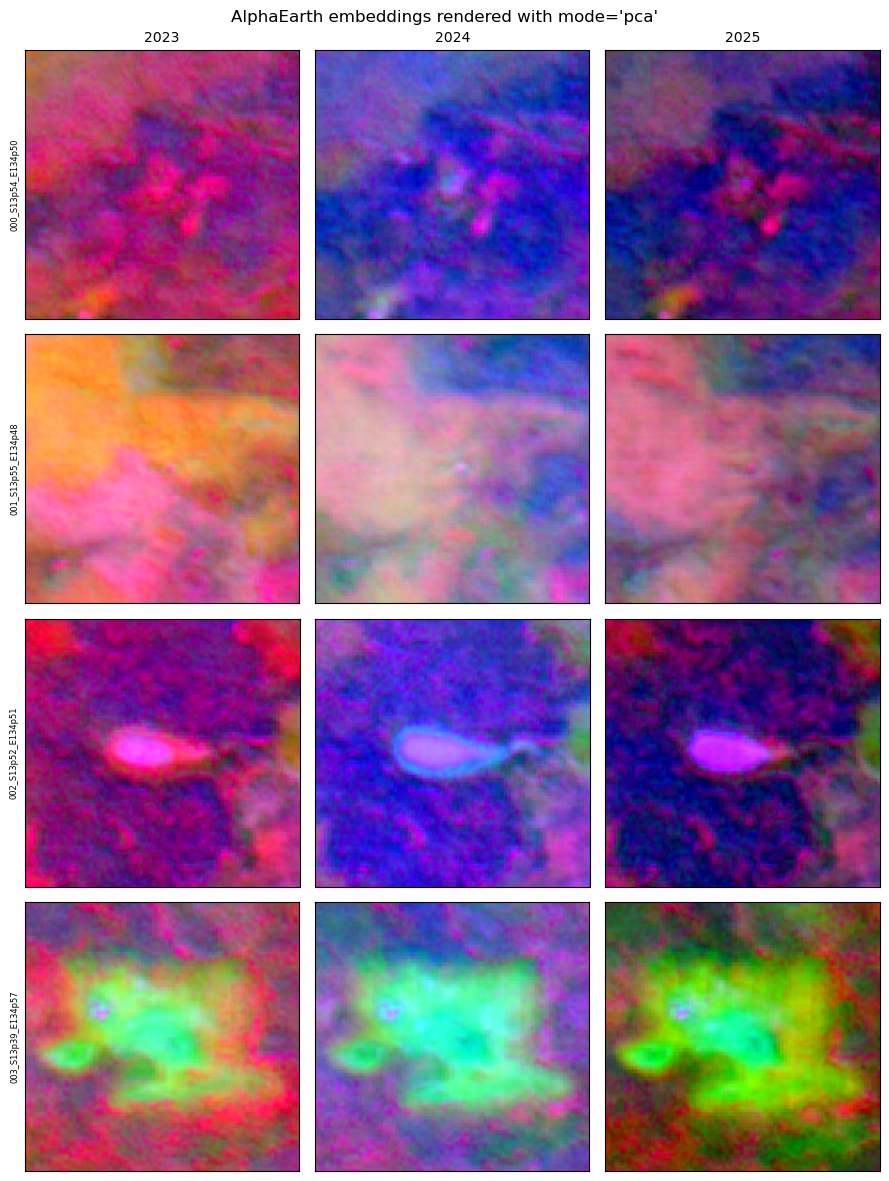

In [23]:
n_preview_aois = 4   # how many AOIs to show

# Group the rendered PNGs by AOI (everything before the trailing _{year})
preview = {}
for path in sorted(png_paths):
    stem = os.path.splitext(os.path.basename(path))[0]
    aoi_key, _, year_key = stem.rpartition('_')
    preview.setdefault(aoi_key, {})[year_key] = path

aoi_keys = sorted(preview)[:n_preview_aois]
year_keys = sorted({y for aoi in aoi_keys for y in preview[aoi]})

if aoi_keys and year_keys:
    fig, axes = plt.subplots(
        len(aoi_keys), len(year_keys),
        figsize=(3 * len(year_keys), 3 * len(aoi_keys)),
        squeeze=False,
    )

    for r, aoi_key in enumerate(aoi_keys):
        for c, year_key in enumerate(year_keys):
            ax = axes[r][c]
            path = preview[aoi_key].get(year_key)
            if path is not None:
                ax.imshow(np.array(Image.open(path)))
            else:
                ax.text(0.5, 0.5, 'missing', ha='center', va='center', fontsize=8)
            if r == 0:
                ax.set_title(year_key, fontsize=10)
            if c == 0:
                ax.set_ylabel('_'.join(aoi_key.split('_')[-3:]), fontsize=6)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(f'AlphaEarth embeddings rendered with mode={render_mode!r}', fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print('No rendered PNGs found to preview.')